# Circle

DISV vertex grid with xugrid

This example models steady-state groundwater flow in a circular domain
using DISV (vertex-based) discretization.  DISV allows arbitrary polygon
cells, which is useful for curvilinear or unstructured domains where a
regular structured grid would introduce excessive staircase error.

Circle example:
* build a `Disv` package from an existing GRB file
* construct an xugrid `Ugrid2d` mesh from the discretization
* convert MODFLOW head and budget output to `UgridDataArray` for plotting
* overlay quiver vectors on an unstructured mesh using `assign_edge_coords()`

### Import dependencies.

In [1]:
import os
from pathlib import Path

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import xugrid as xu
from flopy.mf6.utils.binarygrid_util import MfGrdFile

In [3]:
import flopy4
from flopy4.mf6.enums import NetCDFFormat

### Setup

In [4]:
try:
    CIRCLE_ROOT = Path(__file__).parent
except NameError:
    CIRCLE_ROOT = Path.cwd()

### Define plot function

In [5]:
def plot_head_ugrid(head, cbc, workspace):
    """Plot head and flow vectors using xugrid on a DISV (vertex) grid.

    `gwf.output.head` returns a `UgridDataArray` for DISV models.
    `gwf.output.budget` returns a `UgridDataset` keyed by face-flow term.

    To overlay quiver vectors on an unstructured mesh:
    1. Assemble `u` and `v` (face-normal flow) into a `UgridDataset`.
    2. Call `.ugrid.assign_edge_coords()` to attach edge-centre coordinates
        (`mesh2d_edge_x`, `mesh2d_edge_y`) as xarray coordinates.
    3. Call `.plot.quiver()` using those coordinates as positional arguments.
    """

    cbc_grid = cbc["flow-horizontal-face-x"].grid
    ds = xu.UgridDataset(grids=cbc_grid)
    ds["u"] = cbc["flow-horizontal-face-x"]
    ds["v"] = cbc["flow-horizontal-face-y"]

    # Visualize the results
    ds = ds.ugrid.assign_edge_coords()
    fig, ax = plt.subplots()
    head.isel(time=0, layer=0).compute().ugrid.plot(ax=ax)
    ds.isel(time=0, layer=0).plot.quiver(
        x="mesh2d_edge_x", y="mesh2d_edge_y", u="u", v="v", color="white"
    )
    ax.set_aspect(1)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
    plt.savefig(workspace / "head_ugrid.png", dpi=1200, bbox_inches="tight")
    if not os.environ.get("PYTEST_CURRENT_TEST"):
        plt.show()
    plt.close()

### Timing

In [6]:
# One steady-state stress period of length 1.0 day with a single time step.
time = flopy4.mf6.utils.time.Time(perlen=[1.0], nstp=[1], tsmult=[1.0], time_units="days")
nper = time.nper

### Load from GRB

In [7]:
# Load an existing GRB (binary grid) file to get the DISV geometry.
# A GRB records vertex coordinates, cell connectivity, and grid metadata
# written by MODFLOW 6 after it has processed the DISV package.  Using it
# as the source avoids duplicating the geometry in Python.
grb_fpth = CIRCLE_ROOT / "data" / "circle" / "disv.disv.grb"
grb_obj = MfGrdFile(grb_fpth, verbose=True)
idomain = grb_obj.idomain
xorigin = grb_obj.xorigin
yorigin = grb_obj.yorigin
angrot = grb_obj.angrot


Processing binary grid file: /home/mreon/.clone/dev/pyphoenix-project/docs/examples/data/circle/disv.disv.grb
  File contains data for NCELLS with shape 
  File contains data for NLAY with shape 
  File contains data for NCPL with shape 
  File contains data for NVERT with shape 
  File contains data for NJAVERT with shape 
  File contains data for NJA with shape 
  File contains data for XORIGIN with shape 
  File contains data for YORIGIN with shape 
  File contains data for ANGROT with shape 
  File contains data for TOP with shape (216,)
  File contains data for BOTM with shape (432,)
  File contains data for VERTICES with shape (127, 2)
  File contains data for CELLX with shape (216,)
  File contains data for CELLY with shape (216,)
  File contains data for IAVERT with shape (217,)
  File contains data for JAVERT with shape (864,)
  File contains data for IA with shape (433,)
  File contains data for JA with shape (2088,)
  File contains data for IDOMAIN with shape (432,)
  File 

In [8]:
nlay, ncpl = int(grb_obj.nlay), int(grb_obj.ncpl)
top = np.ravel(grb_obj.top)
botm = grb_obj.bot
botm.shape = (nlay, ncpl)
vertices, cell2d = grb_obj.cell2d

returning iverts from /home/mreon/.clone/dev/pyphoenix-project/docs/examples/data/circle/disv.disv.grb
returning verts from /home/mreon/.clone/dev/pyphoenix-project/docs/examples/data/circle/disv.disv.grb
returning cell centers from /home/mreon/.clone/dev/pyphoenix-project/docs/examples/data/circle/disv.disv.grb


### DISV and Grid

In [9]:
# `Disv` holds the vertex-based discretization.  The grid origin and rotation
# can be set via `xorigin`/`yorigin`/`angrot`.  A CRS string (e.g. "EPSG:26911")
# can be attached for georeferencing.  All are passed to `Disv` at construction time.
disv = flopy4.mf6.gwf.disv.Disv(
    xorigin=573309.700,
    yorigin=4102552.000,
    crs="EPSG:26911",
    length_units="meters",
    nlay=nlay,
    ncpl=ncpl,
    nvert=len(vertices),
    top=top,
    botm=botm,
    idomain=idomain.reshape(nlay, ncpl),
    iv=np.array([v[0] for v in vertices], dtype=int),
    xv=np.array([v[1] for v in vertices], dtype=float),
    yv=np.array([v[2] for v in vertices], dtype=float),
    cell2ddata=flopy4.mf6.gwf.disv.Disv.grid_to_disv_cell2d(cell2d),
)

In [10]:
# Build the xugrid Ugrid2d mesh from the Disv package.
# `disv.to_grid()` returns a `VertexGrid`; `.ugrid` converts it to an
# `xu.Ugrid2d` object suitable for xugrid operations.
grid = disv.to_grid().ugrid

In [11]:
# `dims` captures array shapes needed by packages that pre-allocate xarray storage.
dims = {"nper": nper, "nlay": nlay, "ncpl": ncpl, "nvert": len(vertices), "nodes": nlay * ncpl}

In [12]:
# Wrap idomain as a UgridDataArray so xugrid knows the cell topology.
idomain = xu.UgridDataArray(
    xr.DataArray(
        idomain.reshape(nlay, ncpl),
        coords={"layer": [l + 1 for l in range(nlay)]},
        dims=["layer", grid.face_dimension],
    ),
    grid=grid,
)

### Plot Grid

In [13]:
# Create workspace
workspace = CIRCLE_ROOT / "circle" / "list"
workspace.mkdir(parents=True, exist_ok=True)

/tmp/ipykernel_297002/1750207287.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


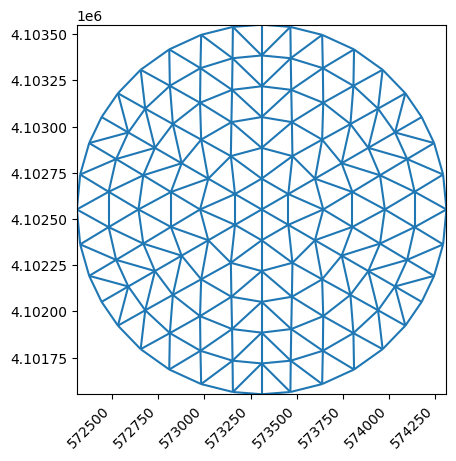

In [14]:
# plot the grid
fig, ax = plt.subplots()
xu.plot.line(grid, ax=ax)
ax.set_aspect(1)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
plt.savefig(workspace / "grid.png", dpi=1200, bbox_inches="tight")
if not os.environ.get("PYTEST_CURRENT_TEST"):
    plt.show()
plt.close()

### Packages

In [15]:
# Initial conditions: uniform starting head of 0.0 m.
ic = flopy4.mf6.gwf.Ic(strt=0.0, dims=dims)

In [16]:
# Node-property flow: isotropic, uniform conductivity; saves specific-discharge
# for vector plotting.
icelltype = xu.full_like(idomain, 0)
k = xu.full_like(idomain, 1.0, dtype=float)
k33 = k.copy()
npf = flopy4.mf6.gwf.Npf(
    # save_specific_discharge=True,
    icelltype=icelltype.values.ravel(),
    k=k.values.ravel(),
    k33=k33.values.ravel(),
    save_flows=True,
    dims=dims,
)

In [17]:
# Storage: steady-state for this single period.
sto = flopy4.mf6.gwf.Sto(
    ss=1.0e-5,
    sy=0.15,
    stress_period_data={0: [("STEADY-STATE",)]},
    iconvert=0,
    dims=dims,
)

In [18]:
# Constant head boundary on the outer ring of cells: `binary_dilation` with
# `border_value=True` identifies all cells that touch the domain boundary.
chd_head = {}
chd_location = xu.zeros_like(idomain.sel(layer=2), dtype=bool).ugrid.binary_dilation(
    border_value=True
)
for i in np.where(chd_location)[0]:
    chd_head[(1, int(i))] = 1.0
chd = flopy4.mf6.gwf.Chd(
    stress_period_data={0: [(cellid, head_val) for cellid, head_val in chd_head.items()]},
    print_input=True,
    print_flows=True,
    save_flows=True,
    dims=dims,
)

In [19]:
# Recharge: uniform rate applied to every cell in the top layer.
rch = flopy4.mf6.gwf.Rch(stress_period_data={0: [((0, j), 0.001) for j in range(ncpl)]}, dims=dims)

In [20]:
# Output control: write heads and budget to binary files.
oc = flopy4.mf6.gwf.Oc(
    budget_file="gwf.bud",
    head_file="gwf.hds",
    stress_period_data={0: [("SAVE", "HEAD", "ALL"), ("SAVE", "BUDGET", "ALL")]},
    dims=dims,
)

### Plot CHD

/tmp/ipykernel_297002/1692941532.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


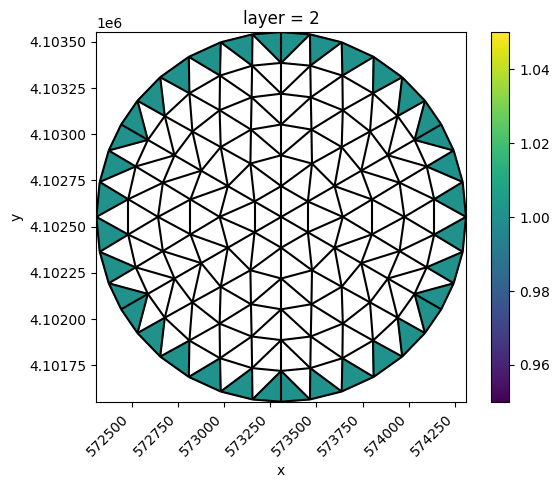

In [21]:
constant_head = xu.full_like(idomain.sel(layer=2), 1.0, dtype=float).where(chd_location)
fig, ax = plt.subplots()
constant_head.ugrid.plot(ax=ax)
xu.plot.line(grid, ax=ax, color="black")
ax.set_aspect(1)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
plt.savefig(workspace / "chd.png", dpi=1200, bbox_inches="tight")
if not os.environ.get("PYTEST_CURRENT_TEST"):
    plt.show()
plt.close()

### Flow Model

In [22]:
# Flow model: assemble GWF model from all packages defined above.
gwf = flopy4.mf6.gwf.Gwf(
    # save_flows=True,
    dis=disv,
    ic=ic,
    npf=npf,
    sto=sto,
    chd=[chd],
    rch=[rch],
    oc=oc,
)

### NetCDF mesh2d output

In [23]:
# When MF6_EXTENDED is set, also write a mesh2d NetCDF output file.
if os.getenv("MF6_EXTENDED"):
    gwf.netcdf_mesh2d_file = Path("circle.nc")

### Solution

In [24]:
# Solver: conjugate-gradient suitable for the symmetric SPD system.
ims = flopy4.mf6.Ims(
    print_option="summary",
    outer_dvclose=1.0e-4,
    outer_maximum=500,
    under_relaxation=None,
    inner_dvclose=1.0e-4,
    rclose=flopy4.mf6.Ims.Rclose(inner_rclose=0.001),
    inner_maximum=100,
    linear_acceleration="cg",
    reordering_method=None,
    relaxation_factor=0.97,
    models=["gwf"],
)

### TDIS

In [25]:
tdis = flopy4.mf6.simulation.Tdis.from_time(time)

### Write and run — list-based inputs

In [26]:
# Create simulation
sim = flopy4.mf6.simulation.Simulation(
    name="circle",
    tdis=tdis,
    models={"gwf": gwf},
    solutions={"ims": ims},
    workspace=workspace,
)

In [27]:
# Write input files and run the simulation
sim.write()
sim.run(verbose=True)  # assumes the ``mf6`` executable is available on your PATH.

running: mf6
stdout:
                               MODFLOW 6 EXTENDED
                U.S. GEOLOGICAL SURVEY MODULAR HYDROLOGIC MODEL
                      VERSION 6.8.0.dev0+c3dbeca123.dirty
                               ***DEVELOP MODE***

        MODFLOW 6 compiled May 16 2026 11:15:15 with GCC version 13.3.0

This software is preliminary or provisional and is subject to 
revision. It is being provided to meet the need for timely best 
science. The software has not received final approval by the U.S. 
Geological Survey (USGS). No warranty, expressed or implied, is made 
by the USGS or the U.S. Government as to the functionality of the 
software and related material nor shall the fact of release 
constitute any such warranty. The software is provided on the 
condition that neither the USGS nor the U.S. Government shall be held 
liable for any damages resulting from the authorized or unauthorized 
use of the software.


 MODFLOW runs in SEQUENTIAL mode

 Run start date and time (yyy

### Read results and plot

In [28]:
# head object from netcdf output — `UgridDataArray` backed by the mesh2d output file.
head = gwf.output.head

In [29]:
# budget object — `UgridDataset` with one variable per face-flow term.
cbc = gwf.output.budget

/tmp/ipykernel_297002/559833197.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


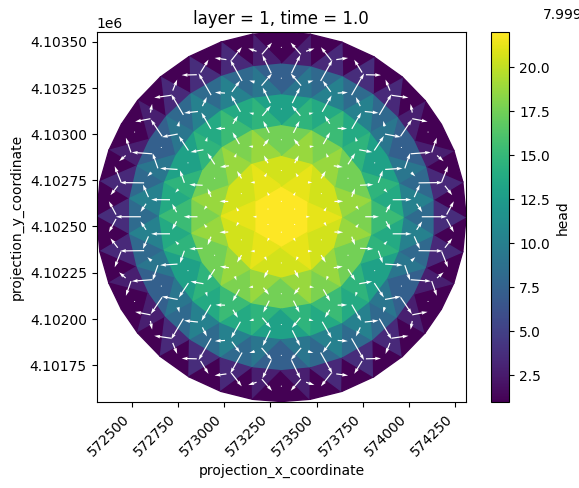

In [30]:
# plot results
plot_head_ugrid(head, cbc, workspace)

### NetCDF input — layered mesh (list-based CHD)

In [31]:
# Re-run with the DISV packages written to a layered-mesh NetCDF file.
# `MF6_EXTENDED=1` is required to run MODFLOW with NetCDF input.
workspace = CIRCLE_ROOT / "circle" / "netcdf"
workspace.mkdir(parents=True, exist_ok=True)
sim.workspace = workspace

In [32]:
nc_fpth = workspace / "circle.input.nc"
gwf.netcdf_input_file = nc_fpth

In [33]:
# Here, grid and time info is passed to the `NetCDFModel' constructor
# so that coordinate and mesh data is written to the NetCDF file.
nc_model = flopy4.mf6.netcdf.NetCDFModel.from_model(
    gwf, netcdf_format=NetCDFFormat.LAYERED_MESH, grid=disv.to_grid(), time=time
)
nc_model.to_netcdf(nc_fpth)

In [34]:
with flopy4.mf6.write_context.WriteContext(use_netcdf=True):
    sim.write()

running: mf6
stdout:
                               MODFLOW 6 EXTENDED
                U.S. GEOLOGICAL SURVEY MODULAR HYDROLOGIC MODEL
                      VERSION 6.8.0.dev0+c3dbeca123.dirty
                               ***DEVELOP MODE***

        MODFLOW 6 compiled May 16 2026 11:15:15 with GCC version 13.3.0

This software is preliminary or provisional and is subject to 
revision. It is being provided to meet the need for timely best 
science. The software has not received final approval by the U.S. 
Geological Survey (USGS). No warranty, expressed or implied, is made 
by the USGS or the U.S. Government as to the functionality of the 
software and related material nor shall the fact of release 
constitute any such warranty. The software is provided on the 
condition that neither the USGS nor the U.S. Government shall be held 
liable for any damages resulting from the authorized or unauthorized 
use of the software.


 MODFLOW runs in SEQUENTIAL mode

 Run start date and time (yyy

/tmp/ipykernel_297002/559833197.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


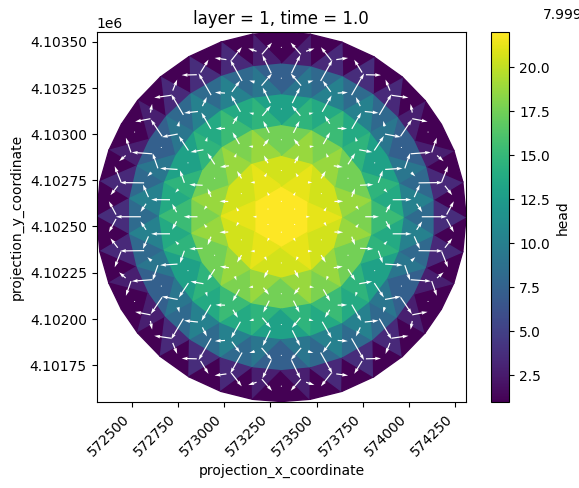

In [35]:
if os.getenv("MF6_EXTENDED"):
    sim.run(verbose=True)

    # head object from netcdf output — `UgridDataArray` backed by the mesh2d output file.
    head = gwf.output.head

    # budget object — `UgridDataset` with one variable per face-flow term.
    cbc = gwf.output.budget

    # plot results
    plot_head_ugrid(head, cbc, workspace)

### Array-based CHD (Chdg)

In [36]:
# Switch from the list-based `Chd` to the array-based `Chdg` and re-run
# with NetCDF input.  Head output is not requested here (no head_file in OC).
GRID_NODATA = np.full((nlay, ncpl), flopy4.mf6.constants.FILL_DNODATA, dtype=float)
head = np.repeat(np.expand_dims(GRID_NODATA, axis=0), repeats=nper, axis=0)
for i in np.where(chd_location)[0]:
    head[0, 1, i] = 1.0

In [37]:
chdg = flopy4.mf6.gwf.Chdg(
    print_input=True,
    print_flows=True,
    save_flows=True,
    head=head.reshape(nper, nlay * ncpl),
    dims=dims,
)

In [38]:
# update chd to chdg
gwf.chd.remove(chd)
gwf.chd = [chdg]

In [39]:
workspace = CIRCLE_ROOT / "circle" / "array"
workspace.mkdir(parents=True, exist_ok=True)
sim.workspace = workspace

In [40]:
nc_fpth = workspace / "circle.input.nc"
gwf.netcdf_input_file = nc_fpth

In [41]:
# Again, with grid and time info
nc_model = flopy4.mf6.netcdf.NetCDFModel.from_model(
    gwf, netcdf_format=NetCDFFormat.LAYERED_MESH, grid=disv.to_grid(), time=time
)
nc_model.to_netcdf(nc_fpth)

In [42]:
with flopy4.mf6.write_context.WriteContext(use_netcdf=True):
    sim.write()

running: mf6
stdout:
                               MODFLOW 6 EXTENDED
                U.S. GEOLOGICAL SURVEY MODULAR HYDROLOGIC MODEL
                      VERSION 6.8.0.dev0+c3dbeca123.dirty
                               ***DEVELOP MODE***

        MODFLOW 6 compiled May 16 2026 11:15:15 with GCC version 13.3.0

This software is preliminary or provisional and is subject to 
revision. It is being provided to meet the need for timely best 
science. The software has not received final approval by the U.S. 
Geological Survey (USGS). No warranty, expressed or implied, is made 
by the USGS or the U.S. Government as to the functionality of the 
software and related material nor shall the fact of release 
constitute any such warranty. The software is provided on the 
condition that neither the USGS nor the U.S. Government shall be held 
liable for any damages resulting from the authorized or unauthorized 
use of the software.


 MODFLOW runs in SEQUENTIAL mode

 Run start date and time (yyy

/tmp/ipykernel_297002/559833197.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


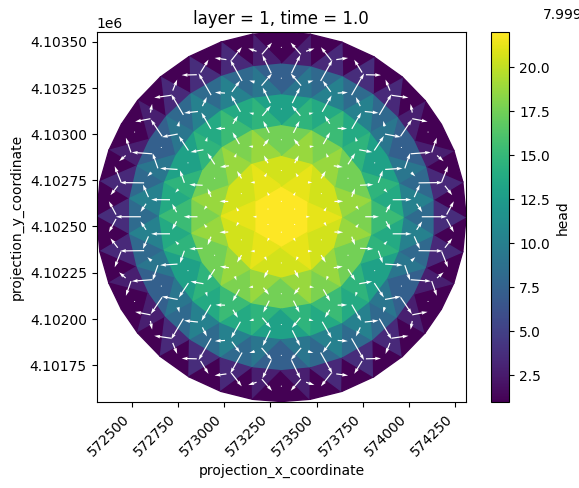

In [43]:
if os.getenv("MF6_EXTENDED"):
    sim.run(verbose=True)

    # Load head results — `UgridDataArray` backed by the NetCDF mesh2d output file.
    head = flopy4.mf6.utils.open_hds(
        workspace / gwf.netcdf_mesh2d_file,
        workspace / f"{gwf.name}.disv.grb",
    )

    # budget object — `UgridDataset` with one variable per face-flow term.
    cbc = gwf.output.budget

    # plot results
    plot_head_ugrid(head, cbc, workspace)